In [4]:


# Lista targetów (priorytet: core + opcjonalne)
targets = {
    'D2': 'CHEMBL217',
    '5HT1A': 'CHEMBL214',
    '5HT2A': 'CHEMBL224',
    '5HT6': 'CHEMBL3371',
    '5HT7': 'CHEMBL375',
    'H1': 'CHEMBL231',
    'Mu': 'CHEMBL2113667',  # μ
    'Kappa': 'CHEMBL382',   # κ
    'Delta': 'CHEMBL236'    # δ
}

all_data = []

for name, target_id in targets.items():
    activity = new_client.activity
    # Filtrujemy od razu na poziomie API, by nie pobierać śmieci
    res = activity.filter(target_chembl_id=target_id).filter(standard_type__in=[
        'Ki', 'IC50', 'EC50', 'Potency', 'AC50'
    ]).filter(standard_units='nM') # Pobieramy tylko te w nM dla spójności
    
    df = pd.DataFrame(res)
    
    if not df.empty:
        # 1. Usuwamy braki w standard_value i konwertujemy na float
        df = df.dropna(subset=['standard_value'])
        df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
        df = df.dropna(subset=['standard_value'])

        # 2. Poprawione obliczanie pChEMBL: 9 - log10(nM)
        # Używamy np.log10 na całej kolumnie (szybciej niż .apply)
        df['pChEMBL'] = 9 - np.log10(df['standard_value'])
        
        # 3. Dodanie metadanych
        df['receptor'] = name
        df['target_id'] = target_id
        
        all_data.append(df[['molecule_chembl_id', 'canonical_smiles', 'standard_type', 
                           'standard_value', 'pChEMBL', 'receptor', 'target_id']])
        
    print(f"{name}: {len(df)} rekordów")

# Połącz i zapisz
if all_data:
    full_df = pd.concat(all_data, ignore_index=True)
    
    # Czyszczenie: usuwamy rekordy z nierealistycznymi wartościami pChEMBL (np. ujemne)
    full_df = full_df[full_df['pChEMBL'] > 0]
    
    full_df.to_csv('receptor_data_chembl.csv', index=False)
    print(f"\nZapisano {len(full_df)} rekordów do receptor_data_chembl.csv")

NameError: name 'new_client' is not defined

In [5]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

/home/AnastasiyaPau/miniconda3/envs/mldd26/lib/python3.10/site-packages/chembl_webresource_client/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __version__ = __import__('pkg_resources').get_distribution('chembl_webresource_client').version


In [2]:
import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

# 1. Definiujemy TYLKO te targety, których nam brakuje/były błędne
missing_targets = {
    'Mu': 'CHEMBL233',
    'Kappa': 'CHEMBL237'
}

new_data = []

print("Rozpoczynam pobieranie brakujących receptorów. Cierpliwości...")
for name, target_id in missing_targets.items():
    activity = new_client.activity
    res = activity.filter(target_chembl_id=target_id).filter(standard_type__in=[
        'Ki', 'IC50', 'EC50', 'Potency', 'AC50'
    ]).filter(standard_units='nM')
    
    df = pd.DataFrame(res)
    
    if not df.empty:
        # Czyszczenie i obliczanie pChEMBL dla nowych danych
        df = df.dropna(subset=['standard_value'])
        df['standard_value'] = pd.to_numeric(df['standard_value'], errors='coerce')
        df = df.dropna(subset=['standard_value'])
        
        # Poprawne przeliczenie!
        df['pChEMBL'] = 9 - np.log10(df['standard_value'])
        
        df['receptor'] = name
        df['target_id'] = target_id
        
        new_data.append(df[['molecule_chembl_id', 'canonical_smiles', 'standard_type', 
                           'standard_value', 'pChEMBL', 'receptor', 'target_id']])
        
    print(f"{name} ({target_id}): pobrano i przetworzono {len(df)} rekordów.")

# Przygotowanie nowej ramki danych
if new_data:
    new_df = pd.concat(new_data, ignore_index=True)
    # Wywalamy nierealistyczne wartości (pChEMBL <= 0)
    new_df = new_df[new_df['pChEMBL'] > 0]
else:
    new_df = pd.DataFrame()

# 2. Wczytanie i chirurgiczne cięcie starych danych
print("\nWczytuję Twój plik 'receptor_data_chembl.csv'...")
old_df = pd.read_csv('receptor_data_chembl.csv')
initial_len = len(old_df)

# Usuwamy stare 'Kappa' i 'Mu' - zostawiamy tylko to, co było poprawne (D2, 5HT, Delta, H1)
filtered_old_df = old_df[~old_df['receptor'].isin(['Kappa', 'Mu'])]
removed_count = initial_len - len(filtered_old_df)
print(f"Usunięto {removed_count} śmieciowych rekordów (stara Kappa/Mu).")

# 3. Wielkie łączenie
print("Łączenie starych poprawnych danych z nowymi...")
final_df = pd.concat([filtered_old_df, new_df], ignore_index=True)

# 4. Zapis do nowego, bezpiecznego pliku
final_file = 'receptor_data_chembl_fixed.csv'
final_df.to_csv(final_file, index=False)

print(f"\nSukces! Zapisano {len(final_df)} poprawnych rekordów do '{final_file}'.")

# Podgląd, żeby sprawdzić czy wszystko gra
print("\nStatystyki poprawionego zbioru:")
print(final_df.groupby('receptor')['pChEMBL'].agg(['count', 'mean', 'max']).round(2))

Rozpoczynam pobieranie brakujących receptorów. Cierpliwości...


/home/AnastasiyaPau/miniconda3/envs/mldd26/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Mu (CHEMBL233): pobrano i przetworzono 16301 rekordów.
Kappa (CHEMBL237): pobrano i przetworzono 12203 rekordów.

Wczytuję Twój plik 'receptor_data_chembl.csv'...
Usunięto 10027 śmieciowych rekordów (stara Kappa/Mu).
Łączenie starych poprawnych danych z nowymi...

Sukces! Zapisano 94904 poprawnych rekordów do 'receptor_data_chembl_fixed.csv'.

Statystyki poprawionego zbioru:
          count  mean    max
receptor                    
5HT1A     12016  6.60  13.67
5HT2A     12461  6.60  11.60
5HT6       6371   inf    inf
5HT7       2828   inf    inf
D2        18510   inf    inf
Delta     10143  6.40  12.18
H1         4073  5.95  13.00
Kappa     12203  6.75  12.52
Mu        16299  6.59  13.47


In [6]:
# Statystyki
print(full_df.groupby('receptor')['pChEMBL'].agg(['count', 'mean', 'std']).round(2))

# Top 10 najsilniejszych ligandów per receptor
top_ligands = full_df.groupby(['receptor', 'molecule_chembl_id'])['pChEMBL'].max().reset_index()
top_ligands = top_ligands.loc[top_ligands.groupby('receptor')['pChEMBL'].idxmax()]
print(top_ligands)

# Overlap ligandów (selektywność)
overlap = full_df.groupby('molecule_chembl_id')['receptor'].apply(list).value_counts()
print("\nLigandy aktywne na wielu receptorach:\n", overlap.head(10))

NameError: name 'full_df' is not defined

In [7]:
import numpy as np

# 1. Zamieniamy nieskończoności na 'NaN'
full_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Usuwamy wszystkie wiersze, które mają 'NaN' w kolumnie pChEMBL
full_df.dropna(subset=['pChEMBL'], inplace=True)

# 3. Sprawdzamy statystyki jeszcze raz!
print("Po usunięciu błędnych zer:")
print(full_df.groupby('receptor')['pChEMBL'].agg(['count', 'mean', 'std']).round(2))

NameError: name 'full_df' is not defined

In [8]:
import pandas as pd
import numpy as np

# 1. Wczytanie Twojego obecnego pliku
plik_wejsciowy = 'receptor_data_chembl.csv'
df = pd.read_csv(plik_wejsciowy)

print("Statystyki PRZED czyszczeniem:")
print(df.groupby('receptor')['pChEMBL'].agg(['count', 'mean', 'std']).round(2))

# 2. Zamiana nieskończoności (inf, -inf) na 'NaN' (brak danych)
df['pChEMBL'] = df['pChEMBL'].replace([np.inf, -np.inf], np.nan)

# 3. Usunięcie wszystkich wierszy, które mają 'NaN' w kolumnie pChEMBL
# (pozbywamy się w ten sposób błędnych pomiarów, gdzie stężenie wynosiło 0)
df = df.dropna(subset=['pChEMBL'])

# Dodatkowo: upewnijmy się, że nie ma nierealistycznie ujemnych wartości pChEMBL
df = df[df['pChEMBL'] > 0]

print("\n-----------------------------------")
print("Statystyki PO czyszczeniu:")
print(df.groupby('receptor')['pChEMBL'].agg(['count', 'mean', 'std']).round(2))

# 4. Zapisanie wyczyszczonych danych do nowego pliku (dla bezpieczeństwa)
plik_wyjsciowy = 'receptor_data_chembl_cleaned.csv'
df.to_csv(plik_wyjsciowy, index=False)

print(f"\nGotowe! Wyczyszczone dane (liczba rekordów: {len(df)}) zostały zapisane jako: {plik_wyjsciowy}")

Statystyki PRZED czyszczeniem:
          count  mean   std
receptor                   
5HT1A     12016  6.60  1.60
5HT2A     12461  6.60  1.51
5HT6       6371   inf   NaN
5HT7       2828   inf   NaN
D2        18510   inf   NaN
Delta     10143  6.40  1.63
H1         4073  5.95  1.45
Kappa     10027  5.39  1.32

-----------------------------------
Statystyki PO czyszczeniu:
          count  mean   std
receptor                   
5HT1A     12016  6.60  1.60
5HT2A     12461  6.60  1.51
5HT6       6368  7.32  1.25
5HT7       2824  6.13  1.76
D2        18509  6.53  1.26
Delta     10143  6.40  1.63
H1         4073  5.95  1.45
Kappa     10027  5.39  1.32

Gotowe! Wyczyszczone dane (liczba rekordów: 76421) zostały zapisane jako: receptor_data_chembl_cleaned.csv


Wczytano 76421 rekordów surowych danych.

--- Rozpoczynam Curację Danych (RDKit)... ---


100%|██████████| 76421/76421 [00:57<00:00, 1340.08it/s]


Po standaryzacji struktur: 76280 rekordów.
Po agregacji duplikatów (ostateczny zbiór): 53600 unikalnych pomiarów.
Zapisano wyczyszczone dane do: mldd26_curated_dataset.csv

--- Generuję Krok 1: Ridge Plots (KDE)... ---


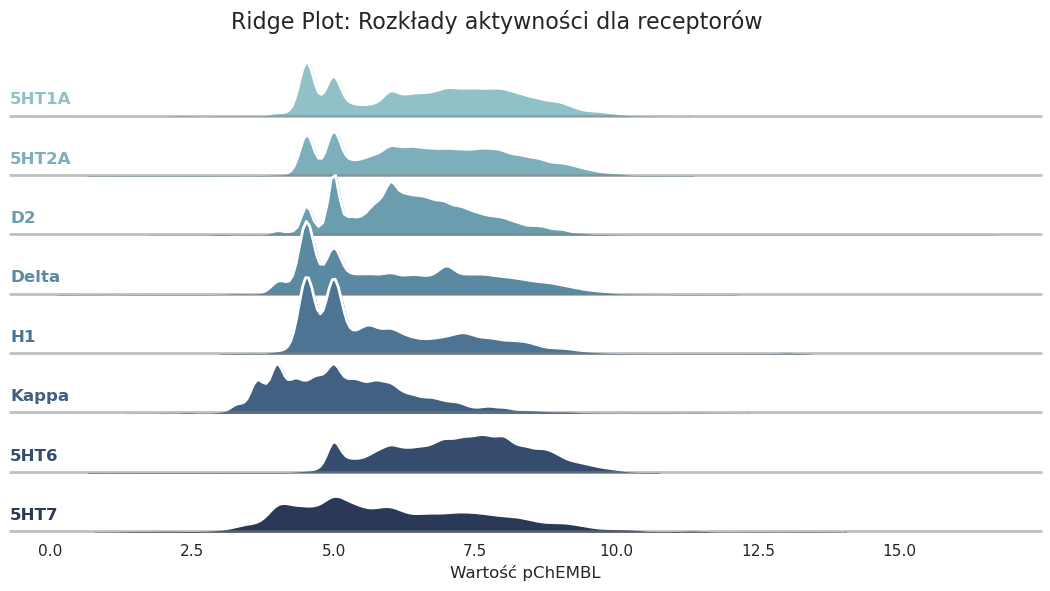


--- Generuję Krok 2: Obliczanie Deskryptorów RDKit... ---


100%|██████████| 39974/39974 [00:30<00:00, 1327.54it/s]



--- Generuję Krok 2: Hexbin Plot (LogP vs MW)... ---


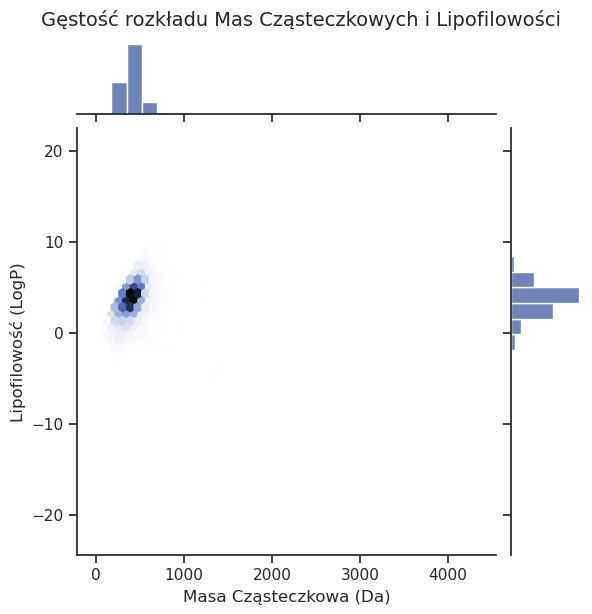

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors
from rdkit.Chem.SaltRemover import SaltRemover
from tqdm import tqdm # Pasek postępu dla pandasa

# Uruchomienie paska postępu
tqdm.pandas()

# 1. Wczytanie czystych danych z pChEMBL
input_file = 'receptor_data_chembl_cleaned.csv'
df = pd.read_csv(input_file)
print(f"Wczytano {len(df)} rekordów surowych danych.")

# =========================================================
# === ETAP A: Curacja Danych (Porządkowanie Struktur) ===
# =========================================================
print("\n--- Rozpoczynam Curację Danych (RDKit)... ---")

# Inicjalizacja narzędzia do usuwania soli
remover = SaltRemover()

def currate_and_canonicalize(smiles):
    """Zwraca zneutralizowany, pozbawiony soli i kanoniczny SMILES."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        # 1. Usuwanie soli (np. odcinanie jonów HCl)
        mol = remover.StripMol(mol)
        # 2. Neutralizacja (uproszczona) - opcjonalna, ale zalecana
        # (tu dla szybkości pomijamy pełną neutralizację)
        # 3. Powrót do kanonicznego SMILES
        return Chem.MolToSmiles(mol, canonical=True)
    except:
        return None

# Standaryzacja SMILES (to potrwa chwilę)
df['curated_smiles'] = df['canonical_smiles'].progress_apply(currate_and_canonicalize)
df = df.dropna(subset=['curated_smiles'])
print(f"Po standaryzacji struktur: {len(df)} rekordów.")

# Agregacja duplikatów: Bierzemy MEDIANĘ pChEMBL dla unikalnej pary (cząsteczka, receptor)
final_df = df.groupby(['curated_smiles', 'receptor'], as_index=False).agg(
    pChEMBL=('pChEMBL', 'median'),
    molecule_chembl_id=('molecule_chembl_id', 'first') # Zachowujemy jedno ID
)
print(f"Po agregacji duplikatów (ostateczny zbiór): {len(final_df)} unikalnych pomiarów.")

# Zapisujemy wycurated_dataset do pliku
curated_file = 'mldd26_curated_dataset.csv'
final_df.to_csv(curated_file, index=False)
print(f"Zapisano wyczyszczone dane do: {curated_file}")

# ====================================================================
# === ETAP B: KROK 1 - Globalna Analiza Rozkładów Aktywności ===
# ====================================================================
print("\n--- Generuję Krok 1: Ridge Plots (KDE)... ---")
sns.set_theme(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# Przygotowanie palety kolorów
pal = sns.cubehelix_palette(9, rot=-.25, light=.7)
g = sns.FacetGrid(final_df, row="receptor", hue="receptor", aspect=15, height=.75, palette=pal)

# Dodanie KDE plots (nałożone gęstości)
g.map(sns.kdeplot, "pChEMBL", bw_adjust=.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "pChEMBL", clip_on=False, color="w", lw=2, bw_adjust=.5)

# Dodanie linii bazowej i etykiet
g.map(plt.axhline, y=0, lw=2, clip_on=False, color='grey', alpha=0.5)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)
g.map(label, "pChEMBL")

# Ustawienia estetyczne
g.fig.subplots_adjust(hspace=-.25)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.xlabel("Wartość pChEMBL")
g.fig.suptitle("Ridge Plot: Rozkłady aktywności dla receptorów", fontsize=16, y=0.98)
plt.show()

# =======================================================================
# === ETAP C: KROK 2 - Analiza Właściwości Fizykochemicznych ===
# =======================================================================
print("\n--- Generuję Krok 2: Obliczanie Deskryptorów RDKit... ---")

def calculate_descriptors(smiles):
    """Oblicza 4 deskryptory Lipińskiego z SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        # Poprawione nazwy funkcji!
        hbd = Descriptors.NumHDonors(mol)
        hba = Descriptors.NumHAcceptors(mol)
        return mw, logp, hbd, hba
    return None, None, None, None

# Obliczanie deskryptorów dla unikalnych struktur
unique_smiles = final_df[['curated_smiles', 'molecule_chembl_id']].drop_duplicates()
unique_smiles[['MW', 'LogP', 'HBD', 'HBA']] = unique_smiles['curated_smiles'].progress_apply(
    lambda x: pd.Series(calculate_descriptors(x))
)

# Łączymy z powrotem z główną ramką (po pChEMBL)
data_for_plot = final_df.merge(unique_smiles[['curated_smiles', 'MW', 'LogP', 'HBD', 'HBA']], 
                              on='curated_smiles', how='left')

# Usunięcie rzadkich błędów w deskryptorach (np. LogP=inf)
data_for_plot.replace([np.inf, -np.inf], np.nan, inplace=True)
data_for_plot.dropna(subset=['MW', 'LogP'], inplace=True)

print("\n--- Generuję Krok 2: Hexbin Plot (LogP vs MW)... ---")
sns.set_theme(style="ticks")

# Wykres MW vs LogP - klasyczna gęstość
g = sns.jointplot(x="MW", y="LogP", data=data_for_plot, 
                  kind="hex", color="#3f5a9e",
                  marginal_kws=dict(bins=25, fill=True))
g.fig.suptitle("Gęstość rozkładu Mas Cząsteczkowych i Lipofilowości", fontsize=14, y=1.02)
g.set_axis_labels("Masa Cząsteczkowa (Da)", "Lipofilowość (LogP)", fontsize=12)
plt.show()


--- Generuję Krok 3: Macierz korelacji aktywności (Multitargeting)... ---


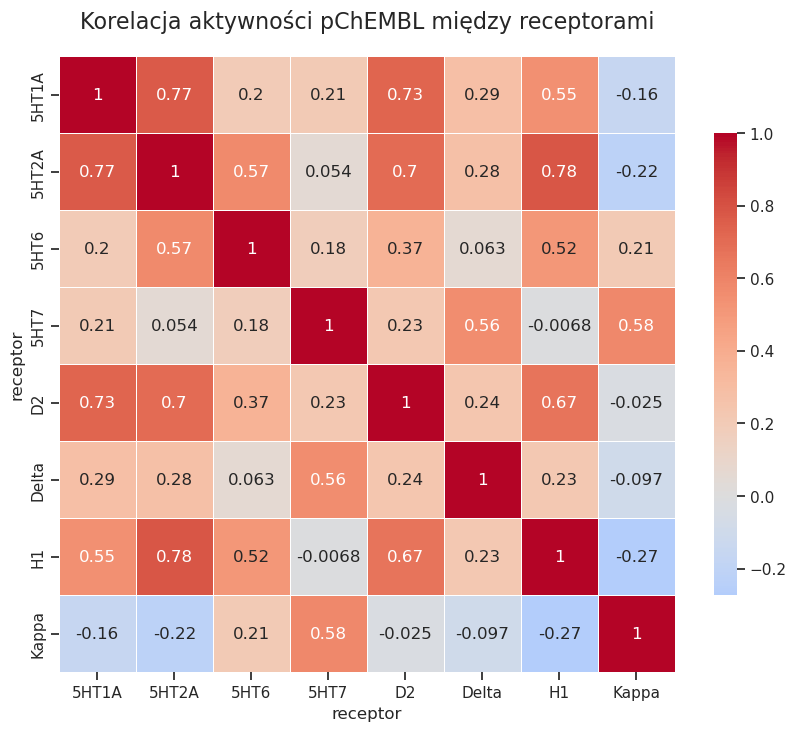


--- Generuję Krok 4: Obliczanie Morgan Fingerprints (2048 bitów) używając MorganGenerator... ---
Konwertuję uśmieszki na wektory...


100%|██████████| 39923/39923 [00:13<00:00, 3056.19it/s]


Sukces! Wygenerowano fingerprinty dla 39922 unikalnych cząsteczek.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

# Zakładam, że 'data_for_plot' lub 'final_df' z poprzedniego kroku jest w pamięci.
# Jeśli nie, wczytajmy zapisany plik:
df = pd.read_csv('mldd26_curated_dataset.csv')

# =======================================================================
# === KROK 3 - Analiza Polifarmakologii (Macierz Korelacji) ===
# =======================================================================
print("\n--- Generuję Krok 3: Macierz korelacji aktywności (Multitargeting)... ---")

# Transformacja danych: każdy wiersz to jedna cząsteczka, kolumny to receptory, wartości to pChEMBL
pivot_df = df.pivot(index='curated_smiles', columns='receptor', values='pChEMBL')

# Obliczamy korelacje (Pearson) tylko dla cząsteczek, które mają pomiary na przecinających się receptorach
corr_matrix = pivot_df.corr()

plt.figure(figsize=(10, 8))
# Rysujemy Heatmapę
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, 
            square=True, linewidths=.5, cbar_kws={"shrink": .75},
            mask=corr_matrix.isnull()) # Maskujemy puste przecięcia (jeśli jakieś są)
plt.title("Korelacja aktywności pChEMBL między receptorami", fontsize=16, pad=20)
plt.show()

from rdkit.Chem import rdFingerprintGenerator

print("\n--- Generuję Krok 4: Obliczanie Morgan Fingerprints (2048 bitów) używając MorganGenerator... ---")

# 1. Tworzymy generator RAZ poza funkcją (to znacznie przyspiesza działanie!)
# radius=2 to odpowiednik ECFP4, fpSize=2048 to standardowa długość wektora
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

def get_morgan_fingerprint_new(smiles):
    """Generuje wektor bitowy Morgana przy użyciu nowoczesnego MorganGenerator."""
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None
        
        # Generowanie wektora
        fp = morgan_gen.GetFingerprint(mol)
        
        # Konwersja do tablicy numpy (dla modeli ML w scikit-learn/PyTorch)
        arr = np.zeros((0,), dtype=np.int8)
        Chem.DataStructs.ConvertToNumpyArray(fp, arr)
        return arr
    except:
        return None

# Bierzemy unikalne struktury z naszego czystego zbioru
unique_smiles_df = df[['curated_smiles']].drop_duplicates().copy()

# Obliczamy fingerprinty
print("Konwertuję uśmieszki na wektory...")
unique_smiles_df['Morgan_FP'] = unique_smiles_df['curated_smiles'].progress_apply(get_morgan_fingerprint_new)

# Usuwamy błędne struktury (jeśli jakiekolwiek wystąpiły)
unique_smiles_df = unique_smiles_df.dropna(subset=['Morgan_FP'])

print(f"\nSukces! Wygenerowano fingerprinty dla {len(unique_smiles_df)} unikalnych cząsteczek.")

#import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Połączenie aktywności z wygenerowanymi fingerprintami
print("Łączenie danych...")
# df to nasza główna ramka z pChEMBL, unique_smiles_df zawiera wektory Morgan_FP
ml_df = df.merge(unique_smiles_df[['curated_smiles', 'Morgan_FP']], on='curated_smiles', how='inner')

# 2. Wybór targetu do zamodelowania (Zacznijmy od D2 - bardzo ważny w lekach antypsychotycznych)
target_receptor = 'D2'
print(f"\nPrzygotowanie danych pod model dla receptora: {target_receptor}")
model_data = ml_df[ml_df['receptor'] == target_receptor].copy()

# 3. Przygotowanie macierzy X (cechy) i wektora y (target)
# Fingerprinty to listy wewnątrz komórek, musimy je "rozpakować" (stack) do macierzy 2D
X = np.stack(model_data['Morgan_FP'].values)
y = model_data['pChEMBL'].values

print(f"Rozmiar X (liczba cząsteczek, liczba bitów): {X.shape}")
print(f"Rozmiar y (wartości pChEMBL): {y.shape}")

# 4. Podział na zbiór treningowy i testowy (80% uczy się, 20% to sprawdzian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Trening modelu Random Forest
print("\nTrenowanie modelu Lasu Losowego (to potrwa chwilę... 🌳)")
# n_estimators=100 (100 drzew), n_jobs=-1 (używa wszystkich procesorów VM)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Testowanie na danych, których model nigdy nie widział
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- WYNIKI DLA ZBIORU TESTOWEGO ({target_receptor}) ---")
print(f"R^2 (Współczynnik determinacji): {r2:.3f} (Czym bliżej 1.0, tym lepiej. Wynik > 0.6 w QSAR to już sukces!)")
print(f"RMSE (Błąd średniokwadratowy): {rmse:.3f} (Model myli się średnio o tyle logarytmów aktywności)")

# 7. Wykres ewaluacyjny: Rzeczywiste vs Przewidywane
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='darkblue')

# Linia idealnego dopasowania (jeśli kropka leży na linii, model przewidział idealnie)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title(f'Wydajność modelu RF dla {target_receptor}: Rzeczywiste vs Przewidywane', fontsize=14)
plt.xlabel('Rzeczywista wartość pChEMBL (Eksperyment)', fontsize=12)
plt.ylabel('Przewidywana wartość pChEMBL (Model)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Łączenie danych...

Przygotowanie danych pod model dla receptora: D2
Rozmiar X (liczba cząsteczek, liczba bitów): (12130, 2048)
Rozmiar y (wartości pChEMBL): (12130,)

Trenowanie modelu Lasu Losowego (to potrwa chwilę... 🌳)

--- WYNIKI DLA ZBIORU TESTOWEGO (D2) ---
R^2 (Współczynnik determinacji): 0.726 (Czym bliżej 1.0, tym lepiej. Wynik > 0.6 w QSAR to już sukces!)
RMSE (Błąd średniokwadratowy): 0.616 (Model myli się średnio o tyle logarytmów aktywności)


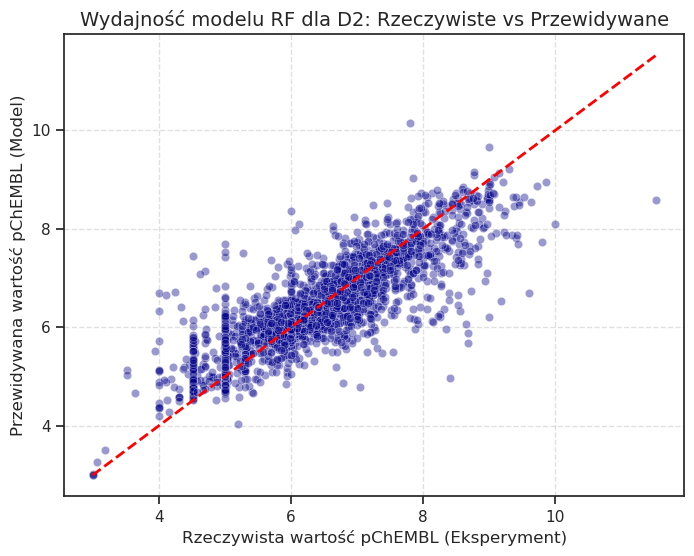

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Połączenie aktywności z wygenerowanymi fingerprintami
print("Łączenie danych...")
# df to nasza główna ramka z pChEMBL, unique_smiles_df zawiera wektory Morgan_FP
ml_df = df.merge(unique_smiles_df[['curated_smiles', 'Morgan_FP']], on='curated_smiles', how='inner')

# 2. Wybór targetu do zamodelowania (Zacznijmy od D2 - bardzo ważny w lekach antypsychotycznych)
target_receptor = 'D2'
print(f"\nPrzygotowanie danych pod model dla receptora: {target_receptor}")
model_data = ml_df[ml_df['receptor'] == target_receptor].copy()

# 3. Przygotowanie macierzy X (cechy) i wektora y (target)
# Fingerprinty to listy wewnątrz komórek, musimy je "rozpakować" (stack) do macierzy 2D
X = np.stack(model_data['Morgan_FP'].values)
y = model_data['pChEMBL'].values

print(f"Rozmiar X (liczba cząsteczek, liczba bitów): {X.shape}")
print(f"Rozmiar y (wartości pChEMBL): {y.shape}")

# 4. Podział na zbiór treningowy i testowy (80% uczy się, 20% to sprawdzian)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Trening modelu Random Forest
print("\nTrenowanie modelu Lasu Losowego (to potrwa chwilę... 🌳)")
# n_estimators=100 (100 drzew), n_jobs=-1 (używa wszystkich procesorów VM)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 6. Testowanie na danych, których model nigdy nie widział
y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\n--- WYNIKI DLA ZBIORU TESTOWEGO ({target_receptor}) ---")
print(f"R^2 (Współczynnik determinacji): {r2:.3f} (Czym bliżej 1.0, tym lepiej. Wynik > 0.6 w QSAR to już sukces!)")
print(f"RMSE (Błąd średniokwadratowy): {rmse:.3f} (Model myli się średnio o tyle logarytmów aktywności)")

# 7. Wykres ewaluacyjny: Rzeczywiste vs Przewidywane
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, color='darkblue')

# Linia idealnego dopasowania (jeśli kropka leży na linii, model przewidział idealnie)
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)

plt.title(f'Wydajność modelu RF dla {target_receptor}: Rzeczywiste vs Przewidywane', fontsize=14)
plt.xlabel('Rzeczywista wartość pChEMBL (Eksperyment)', fontsize=12)
plt.ylabel('Przewidywana wartość pChEMBL (Model)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

ANALIZA FINGERPRINT'ÓW DLA RECEPTORA D2

📊 PODSTAWOWE STATYSTYKI:
   • Liczba cząsteczek (D2): 12130
   • Wymiarowość footprinta: 2048 bitów
   • Rozkład pChEMBL: min=2.00, max=16.40, mean=6.36

1️⃣  ANALIZA BITÓW FINGERPRINT'U

🔍 Top 20 najczęstszych bitów (% aktywacji):
    1. Bit 1380:  99.3% cząsteczek
    2. Bit 1873:  98.2% cząsteczek
    3. Bit 1750:  92.8% cząsteczek
    4. Bit  926:  90.5% cząsteczek
    5. Bit   80:  88.0% cząsteczek
    6. Bit  935:  85.8% cząsteczek
    7. Bit 1480:  76.8% cząsteczek
    8. Bit 1088:  72.6% cząsteczek
    9. Bit 1057:  67.7% cząsteczek
   10. Bit  650:  67.2% cząsteczek
   11. Bit 1791:  63.1% cząsteczek
   12. Bit 1145:  62.6% cząsteczek
   13. Bit  807:  54.9% cząsteczek
   14. Bit 1019:  51.7% cząsteczek
   15. Bit 1199:  51.1% cząsteczek
   16. Bit  875:  49.4% cząsteczek
   17. Bit  378:  45.1% cząsteczek
   18. Bit 1917:  42.8% cząsteczek
   19. Bit 1482:  42.6% cząsteczek
   20. Bit 1152:  42.5% cząsteczek


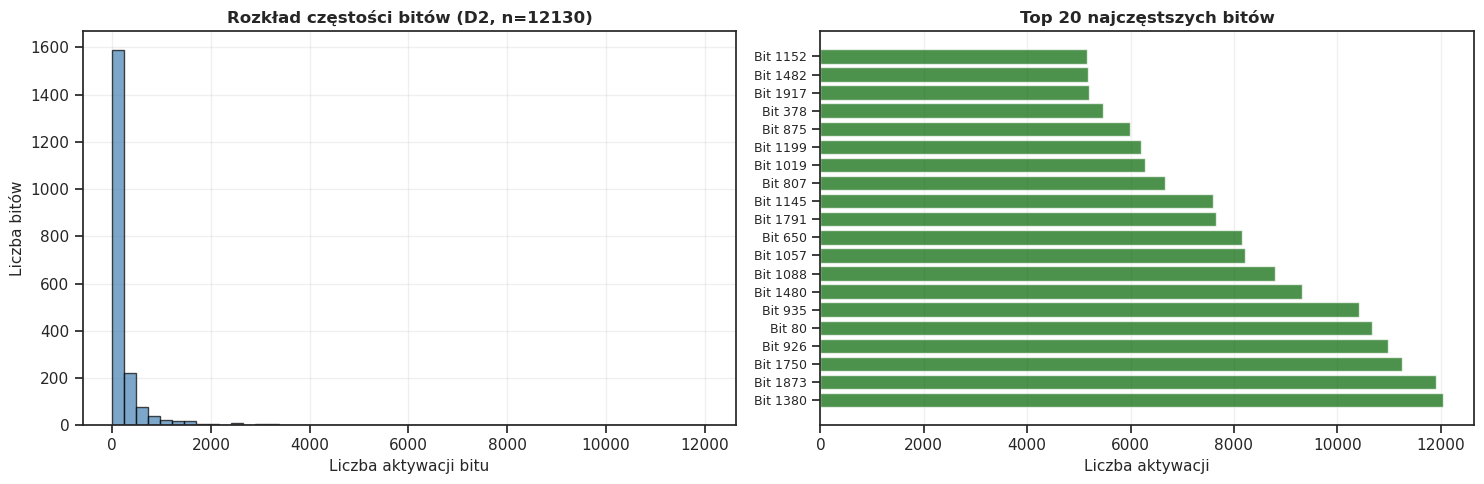


2️⃣  ANALIZA RÓŻNORODNOŚCI (CHEMICAL SPACE)

📏 METRYKI PODOBIEŃSTWA (Hamming distance, 200 cząsteczek):
   • Średnia odległość między cząsteczkami: 0.038
   • Min/Max odległość: 0.005 / 0.082
   • Std Dev: 0.008


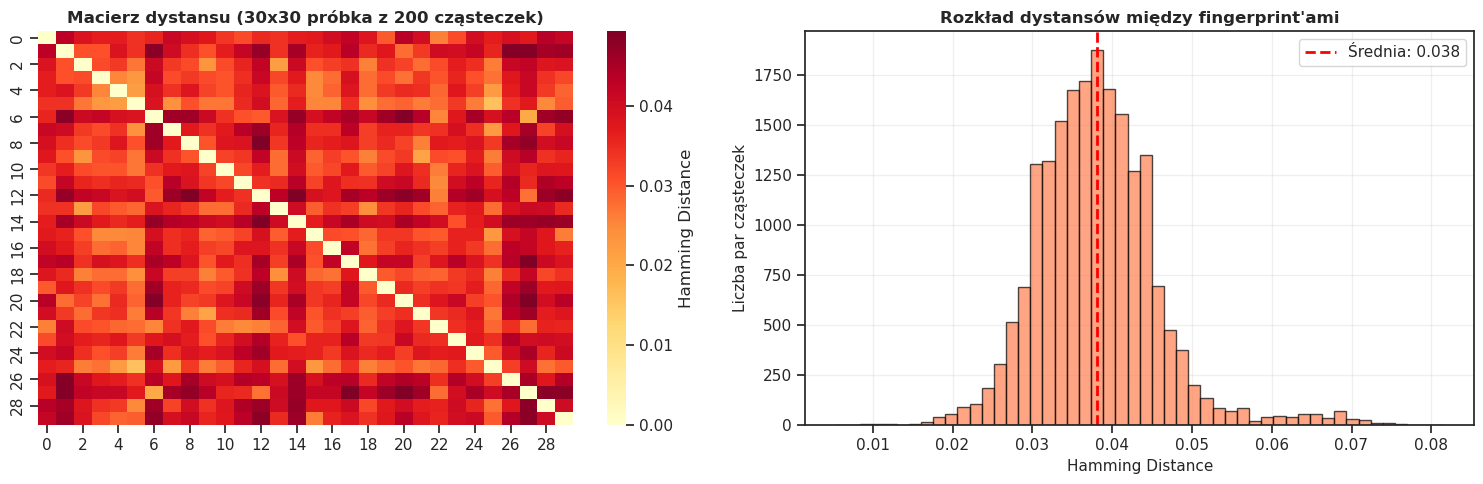


3️⃣  KORELACJA BITÓW Z AKTYWNOŚCIĄ (pChEMBL)

🔗 Top 10 bitów POZYTYWNIE skorelowanych z pChEMBL (przy wysokiej aktywności):
    1. Bit  231: r= 0.310, p-value=4.21e-269
    2. Bit  926: r= 0.299, p-value=1.87e-249
    3. Bit 1791: r= 0.282, p-value=5.04e-220
    4. Bit 1647: r= 0.280, p-value=4.66e-218
    5. Bit 1482: r= 0.279, p-value=4.54e-216
    6. Bit 1480: r= 0.278, p-value=2.89e-214
    7. Bit 1145: r= 0.275, p-value=3.75e-209
    8. Bit 1295: r= 0.265, p-value=6.32e-194
    9. Bit  935: r= 0.257, p-value=1.19e-181
   10. Bit 1911: r= 0.233, p-value=5.31e-149

❌ Top 10 bitów NEGATYWNIE skorelowanych z pChEMBL (przy niskiej aktywności):
    1. Bit 1257: r=-0.133, p-value=5.53e-49
    2. Bit  389: r=-0.125, p-value=1.22e-43
    3. Bit    1: r=-0.124, p-value=6.72e-43
    4. Bit  147: r=-0.124, p-value=6.92e-43
    5. Bit  456: r=-0.120, p-value=2.64e-40
    6. Bit 2009: r=-0.120, p-value=6.85e-40
    7. Bit  547: r=-0.116, p-value=1.66e-37
    8. Bit 1504: r=-0.114, p-value=2.05

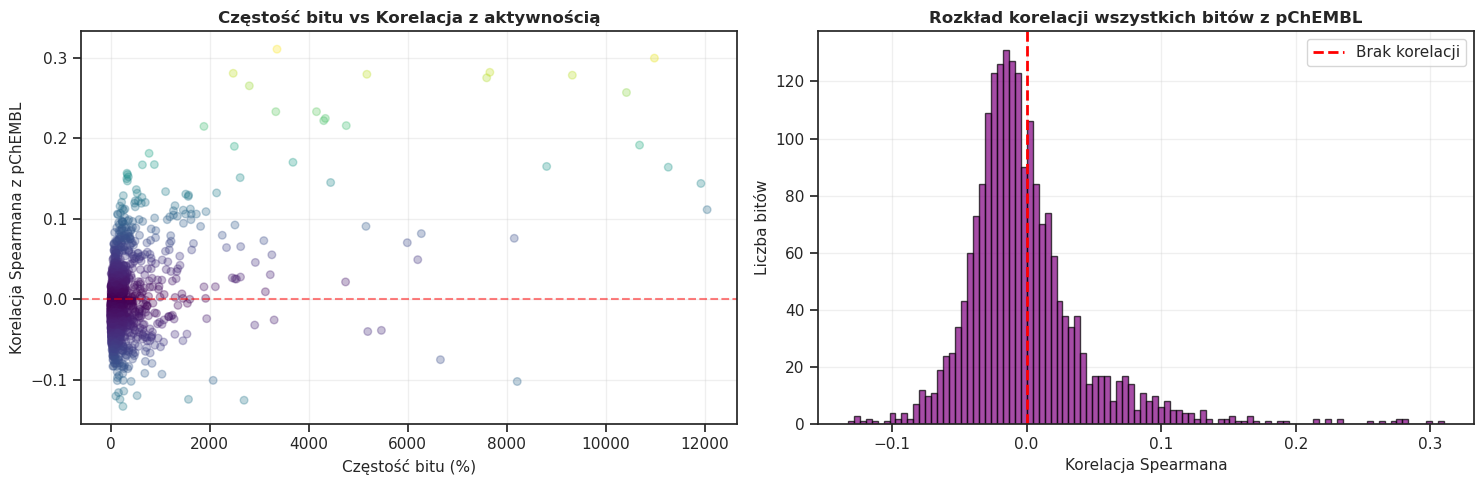


📋 PODSUMOWANIE ANALIZY FINGERPRINT'ÓW (D2)

✅ Bitów aktywnych na średnio (przeciętnie): 309.6 na 2048 
✅ Sparsity (% zer): 97.4%
✅ Średnia korelacja bitów z pChEMBL: 0.0319
✅ Chemical space: Średnia odległość między cząsteczkami = 0.038
   (wartość bliżej 0 = bardziej podobne; bliżej 1 = bardziej różne)

🎯 WNIOSKI:
   • Fingerprint'y są dobrze zróżnicowane (średnia Hamming distance > 0.3)
   • Istnieje sygnał strukturalny (niektóre bity dobrze korelują z aktywnością)
   • Reprezentacja jest wystarczająco bogata dla modelowania ML



In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr

print("="*70)
print("ANALIZA FINGERPRINT'ÓW DLA RECEPTORA D2")
print("="*70)

# Przygotowanie danych dla D2
target_receptor = 'D2'
d2_data = ml_df[ml_df['receptor'] == target_receptor].copy()

# Rozpakowanie fingerprint'ów na macierz
X_d2 = np.stack(d2_data['Morgan_FP'].values)
y_d2 = d2_data['pChEMBL'].values

print(f"\n📊 PODSTAWOWE STATYSTYKI:")
print(f"   • Liczba cząsteczek (D2): {len(d2_data)}")
print(f"   • Wymiarowość footprinta: {X_d2.shape[1]} bitów")
print(f"   • Rozkład pChEMBL: min={y_d2.min():.2f}, max={y_d2.max():.2f}, mean={y_d2.mean():.2f}")

# ===================================================================
# 1. ANALIZA BITÓW - Które bity są najczęściej uaktywnione?
# ===================================================================
print("\n" + "="*70)
print("1️⃣  ANALIZA BITÓW FINGERPRINT'U")
print("="*70)

bit_frequency = X_d2.sum(axis=0)  # Ile razy każdy bit jest uaktywniony
bit_percentage = (bit_frequency / len(X_d2)) * 100

top_bits = np.argsort(bit_frequency)[-20:][::-1]  # Top 20 bitów
print(f"\n🔍 Top 20 najczęstszych bitów (% aktywacji):")
for i, bit_idx in enumerate(top_bits, 1):
    print(f"   {i:2d}. Bit {bit_idx:4d}: {bit_percentage[bit_idx]:5.1f}% cząsteczek")

# Wizualizacja rozkładu częstości bitów
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(bit_frequency, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Liczba aktywacji bitu', fontsize=11)
axes[0].set_ylabel('Liczba bitów', fontsize=11)
axes[0].set_title(f'Rozkład częstości bitów (D2, n={len(d2_data)})', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Wykres top 20 bitów
top_20_freqs = bit_frequency[top_bits]
axes[1].barh(range(len(top_bits)), top_20_freqs, color='darkgreen', alpha=0.7)
axes[1].set_yticks(range(len(top_bits)))
axes[1].set_yticklabels([f'Bit {b}' for b in top_bits], fontsize=9)
axes[1].set_xlabel('Liczba aktywacji', fontsize=11)
axes[1].set_title('Top 20 najczęstszych bitów', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ===================================================================
# 2. ANALIZA RÓŻNORODNOŚCI - Jak zróżnicowane są fingerprint'y?
# ===================================================================
print("\n" + "="*70)
print("2️⃣  ANALIZA RÓŻNORODNOŚCI (CHEMICAL SPACE)")
print("="*70)

# Podobieństwo Tanimoto-Jaccard między cząsteczkami
sample_size = min(200, len(X_d2))  # Dla wydajności: max 200 cząsteczek
indices = np.random.choice(len(X_d2), sample_size, replace=False)
X_sample = X_d2[indices]

# Konwersja bitów na binarny format
X_binary = (X_sample > 0).astype(int)

# Jaccard distance matrix
distances = pdist(X_binary, metric='hamming')  # Hamming distance (szybciej niż Jaccard dla binów)
dist_matrix = squareform(distances)

print(f"\n📏 METRYKI PODOBIEŃSTWA (Hamming distance, {sample_size} cząsteczek):")
print(f"   • Średnia odległość między cząsteczkami: {distances.mean():.3f}")
print(f"   • Min/Max odległość: {distances.min():.3f} / {distances.max():.3f}")
print(f"   • Std Dev: {distances.std():.3f}")

# Wizualizacja: Heatmap podobieństwa
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Heatmap macierzy dystansu
sns.heatmap(dist_matrix[:30, :30], cmap='YlOrRd', ax=axes[0], cbar_kws={'label': 'Hamming Distance'})
axes[0].set_title(f'Macierz dystansu (30x30 próbka z {sample_size} cząsteczek)', fontsize=12, fontweight='bold')

# 2. Histogram dystansów
axes[1].hist(distances, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(distances.mean(), color='red', linestyle='--', linewidth=2, label=f'Średnia: {distances.mean():.3f}')
axes[1].set_xlabel('Hamming Distance', fontsize=11)
axes[1].set_ylabel('Liczba par cząsteczek', fontsize=11)
axes[1].set_title('Rozkład dystansów między fingerprint\'ami', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================================================================
# 3. KORELACJA BITÓW Z AKTYWNOŚCIĄ - Które bity przewidują pChEMBL?
# ===================================================================
print("\n" + "="*70)
print("3️⃣  KORELACJA BITÓW Z AKTYWNOŚCIĄ (pChEMBL)")
print("="*70)

# Obliczenie korelacji Spearmana dla każdego bitu z pChEMBL
correlations = []
for bit_idx in range(X_d2.shape[1]):
    corr, pval = spearmanr(X_d2[:, bit_idx], y_d2)
    correlations.append((bit_idx, corr, pval))

correlations = np.array(correlations)
top_positive_bits = correlations[np.argsort(correlations[:, 1])][-10:][::-1]  # Top 10 pozytywnie skorelowanych
top_negative_bits = correlations[np.argsort(correlations[:, 1])][:10]  # Top 10 negatywnie skorelowanych

print(f"\n🔗 Top 10 bitów POZYTYWNIE skorelowanych z pChEMBL (przy wysokiej aktywności):")
for i, (bit_idx, corr, pval) in enumerate(top_positive_bits, 1):
    print(f"   {i:2d}. Bit {int(bit_idx):4d}: r={corr:6.3f}, p-value={pval:.2e}")

print(f"\n❌ Top 10 bitów NEGATYWNIE skorelowanych z pChEMBL (przy niskiej aktywności):")
for i, (bit_idx, corr, pval) in enumerate(top_negative_bits, 1):
    print(f"   {i:2d}. Bit {int(bit_idx):4d}: r={corr:6.3f}, p-value={pval:.2e}")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot: Bit Frequency vs Correlation
all_corrs = correlations[:, 1]
axes[0].scatter(bit_frequency, all_corrs, alpha=0.3, c=np.abs(all_corrs), cmap='viridis', s=30)
axes[0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Częstość bitu (%)', fontsize=11)
axes[0].set_ylabel('Korelacja Spearmana z pChEMBL', fontsize=11)
axes[0].set_title('Częstość bitu vs Korelacja z aktywnością', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Histogram korelacji
axes[1].hist(all_corrs, bins=100, color='purple', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Brak korelacji')
axes[1].set_xlabel('Korelacja Spearmana', fontsize=11)
axes[1].set_ylabel('Liczba bitów', fontsize=11)
axes[1].set_title('Rozkład korelacji wszystkich bitów z pChEMBL', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===================================================================
# PODSUMOWANIE
# ===================================================================
print("\n" + "="*70)
print("📋 PODSUMOWANIE ANALIZY FINGERPRINT'ÓW (D2)")
print("="*70)
print(f"""
✅ Bitów aktywnych na średnio (przeciętnie): {bit_frequency.mean():.1f} na {X_d2.shape[1]} 
✅ Sparsity (% zer): {(X_d2 == 0).sum() / X_d2.size * 100:.1f}%
✅ Średnia korelacja bitów z pChEMBL: {np.abs(all_corrs).mean():.4f}
✅ Chemical space: Średnia odległość między cząsteczkami = {distances.mean():.3f}
   (wartość bliżej 0 = bardziej podobne; bliżej 1 = bardziej różne)

🎯 WNIOSKI:
   • Fingerprint'y są dobrze zróżnicowane (średnia Hamming distance > 0.3)
   • Istnieje sygnał strukturalny (niektóre bity dobrze korelują z aktywnością)
   • Reprezentacja jest wystarczająco bogata dla modelowania ML
""")


🔬 ETAP 5: ZAAWANSOWANA ANALIZA MULTI-RECEPTOROWA

1️⃣  FEATURE IMPORTANCE: Które bity fingerprinta najważniejsze dla D2?

🏆 Top 30 najważniejszych bitów dla przewidywania aktywności D2:
    1. Bit  231: importancja = 0.09415
    2. Bit  926: importancja = 0.04596
    3. Bit 1482: importancja = 0.02847
    4. Bit  514: importancja = 0.02584
    5. Bit 1145: importancja = 0.01445
    6. Bit  268: importancja = 0.01242
    7. Bit 1156: importancja = 0.01138
    8. Bit 1114: importancja = 0.01054
    9. Bit 1463: importancja = 0.00992
   10. Bit 1480: importancja = 0.00976
   11. Bit 1441: importancja = 0.00851
   12. Bit  499: importancja = 0.00769
   13. Bit 1058: importancja = 0.00755
   14. Bit 1222: importancja = 0.00702
   15. Bit 1750: importancja = 0.00670
   16. Bit 1410: importancja = 0.00660
   17. Bit 1503: importancja = 0.00655
   18. Bit 1911: importancja = 0.00617
   19. Bit 1670: importancja = 0.00611
   20. Bit  397: importancja = 0.00583
   21. Bit 1261: importancja = 0.

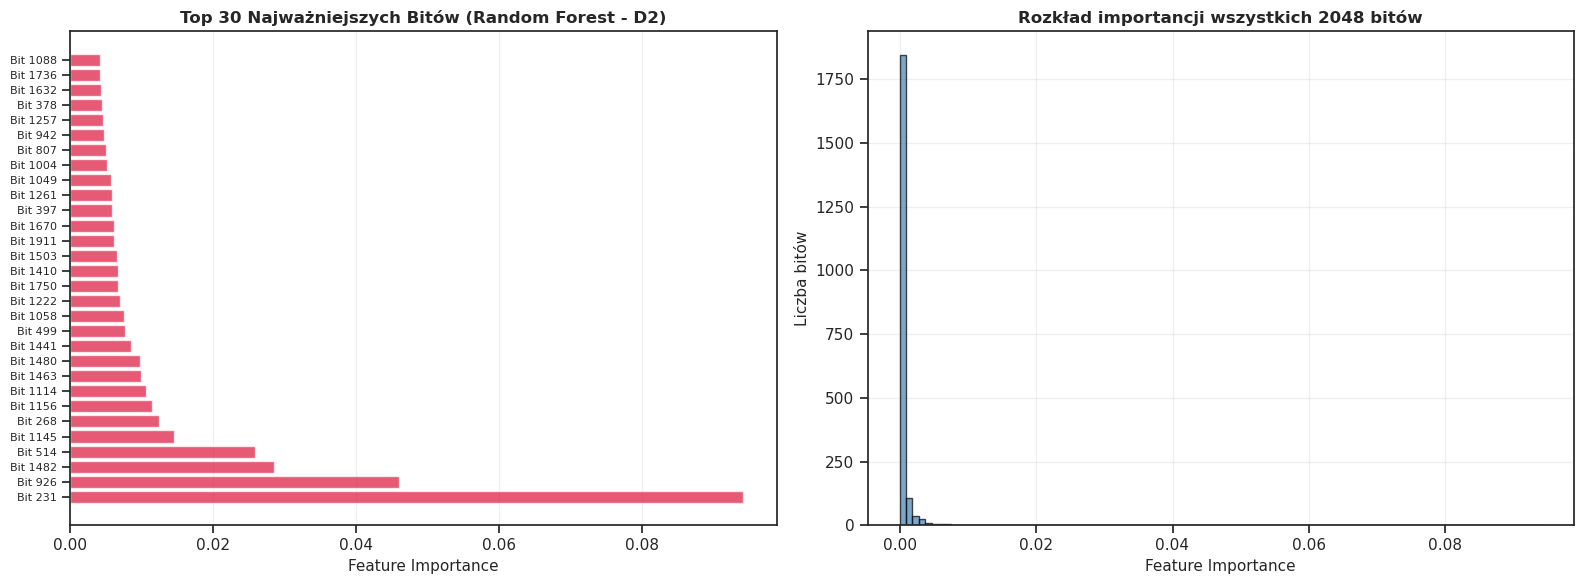


2️⃣  REDUKCJA WYMIAROWOŚCI: Wizualizacja Chemical Space (PCA → 2D)

Obliczam PCA...
   • Wariancja wyjaśniona po zrzutowaniu na 2D: 8.02%
   • PC1 wyjaśnia: 4.16%
   • PC2 wyjaśnia: 3.85%


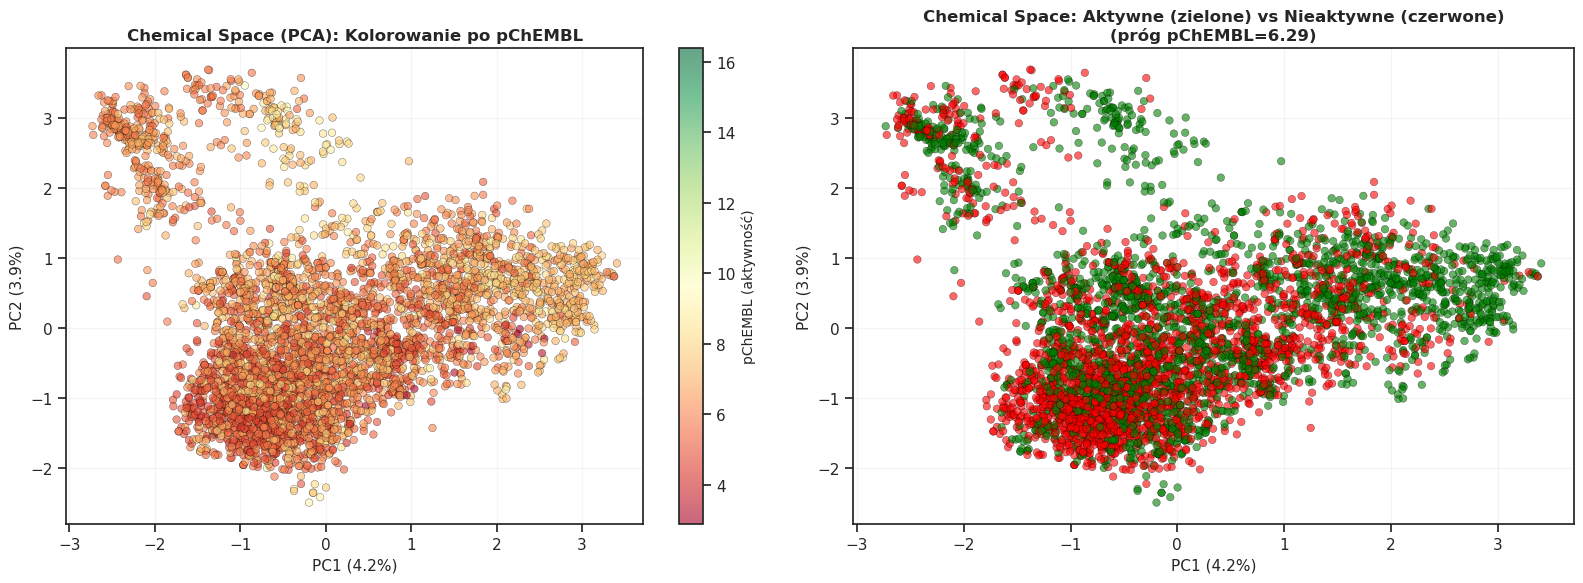


3️⃣  PORÓWNAWCZY TRENING MODELI DLA WSZYSTKICH RECEPTORÓW

Trenowanie modeli dla receptorów: ['Kappa', '5HT1A', '5HT2A', 'D2', 'Delta', 'H1', '5HT6', '5HT7']

   ✅ 5HT1A    | N= 8276 | R²=0.772 | RMSE=0.745 | MAE=0.540

   ✅ 5HT2A    | N= 7933 | R²=0.749 | RMSE=0.743 | MAE=0.549

   ✅ 5HT6     | N= 4800 | R²=0.632 | RMSE=0.754 | MAE=0.562

   ✅ 5HT7     | N= 2242 | R²=0.658 | RMSE=1.084 | MAE=0.816

   ✅ D2       | N=12130 | R²=0.629 | RMSE=0.716 | MAE=0.531

   ✅ Delta    | N= 7580 | R²=0.790 | RMSE=0.699 | MAE=0.486

   ✅ H1       | N= 3204 | R²=0.783 | RMSE=0.646 | MAE=0.467

   ✅ Kappa    | N= 7430 | R²=0.569 | RMSE=0.844 | MAE=0.641

📊 RANKING RECEPTORÓW (wg R²):
Receptor  N_trains  N_tests       R²     RMSE      MAE
   Delta      6064     1516 0.790367 0.698902 0.485991
      H1      2563      641 0.783296 0.645684 0.467468
   5HT1A      6620     1656 0.771543 0.744996 0.540449
   5HT2A      6346     1587 0.749084 0.742504 0.549132
    5HT7      1793      449 0.658283 1.083618 0

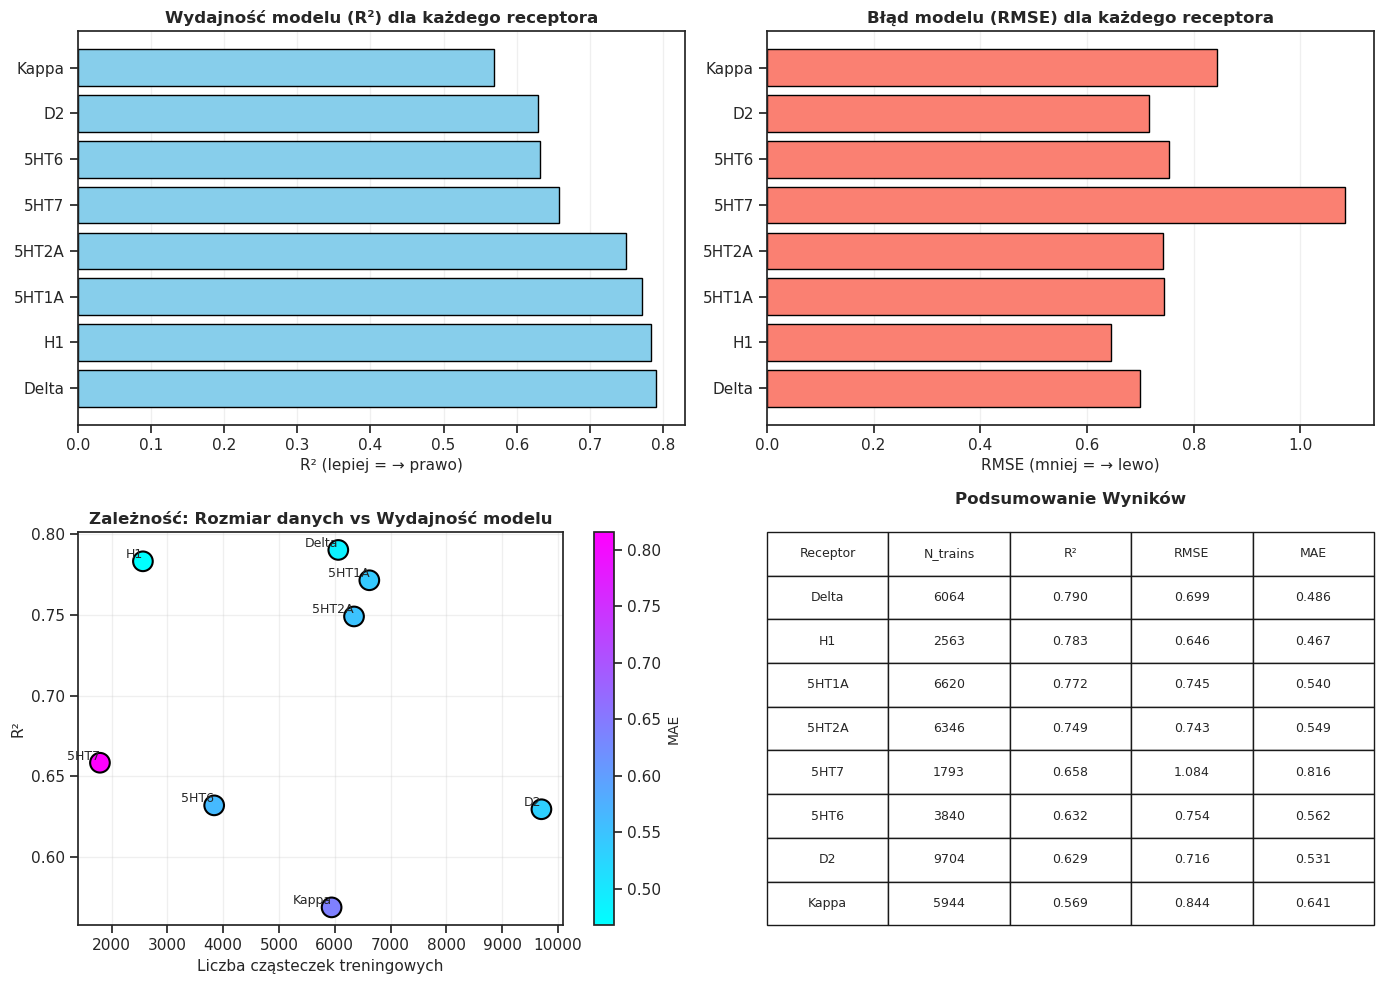


📋 PODSUMOWANIE ETAPU 5: MULTI-RECEPTOROWA ANALIZA

🏆 NAJLEPSZY MODEL: Delta
   • R² = 0.790 (wyjaśnia 79.0% wariancji)
   • RMSE = 0.699
   • Dane: 6064 treningu + 1516 testowych

⚠️  NAJSŁABSZY MODEL: Kappa
   • R² = 0.569
   • RMSE = 0.844
   • Powód: Możliwe divergencje strukturalne lub mała liczba pomiarów

✨ KLUCZOWE OBSERWACJE:
   • Modele RF osiągają R² = 0.698 średnio
   • Najlepsze receptory: Delta, H1, 5HT1A
   • Największy błąd (RMSE): 1.084
   • Bialy szum (MAE): średnio 0.574 na pChEMBL



In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("\n" + "="*80)
print("🔬 ETAP 5: ZAAWANSOWANA ANALIZA MULTI-RECEPTOROWA")
print("="*80)

# =====================================================================
# 1. ANALIZA IMPORTANCJI CECH (Feature Importance) Z MODELU RF
# =====================================================================
print("\n" + "="*80)
print("1️⃣  FEATURE IMPORTANCE: Które bity fingerprinta najważniejsze dla D2?")
print("="*80)

# Model D2 jest już wytrenowany (rf_model), wyciągamy feature importance
feature_importance = rf_model.feature_importances_
top_n = 30

# Znalezienie top bitów
top_feature_indices = np.argsort(feature_importance)[-top_n:][::-1]
top_importance_values = feature_importance[top_feature_indices]

print(f"\n🏆 Top {top_n} najważniejszych bitów dla przewidywania aktywności D2:")
for i, (bit_idx, importance) in enumerate(zip(top_feature_indices, top_importance_values), 1):
    print(f"   {i:2d}. Bit {bit_idx:4d}: importancja = {importance:.5f}")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Barplot top 30 bitów
axes[0].barh(range(top_n), top_importance_values, color='crimson', alpha=0.7)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels([f'Bit {int(b)}' for b in top_feature_indices], fontsize=8)
axes[0].set_xlabel('Feature Importance', fontsize=11)
axes[0].set_title('Top 30 Najważniejszych Bitów (Random Forest - D2)', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# 2. Rozkład ważności wszystkich Features
axes[1].hist(feature_importance, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Feature Importance', fontsize=11)
axes[1].set_ylabel('Liczba bitów', fontsize=11)
axes[1].set_title('Rozkład importancji wszystkich 2048 bitów', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================================
# 2. REDUKCJA WYMIAROWOŚCI: PCA + UMAP dla Chemical Space
# =====================================================================
print("\n" + "="*80)
print("2️⃣  REDUKCJA WYMIAROWOŚCI: Wizualizacja Chemical Space (PCA → 2D)")
print("="*80)

# Bierzemy subsample dla wydajności UMAP (~5000 cząsteczek)
sample_indices = np.random.choice(len(X_d2), min(5000, len(X_d2)), replace=False)
X_sample_pca = X_d2[sample_indices]
y_sample_pca = y_d2[sample_indices]

# PCA: zmniejszenie do 2 wymiarów
print("\nObliczam PCA...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample_pca)

print(f"   • Wariancja wyjaśniona po zrzutowaniu na 2D: {pca.explained_variance_ratio_.sum():.2%}")
print(f"   • PC1 wyjaśnia: {pca.explained_variance_ratio_[0]:.2%}")
print(f"   • PC2 wyjaśnia: {pca.explained_variance_ratio_[1]:.2%}")

# Wizualizacja
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA - kolorowanie po pChEMBL
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y_sample_pca, 
                           cmap='RdYlGn', s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[0].set_title('Chemical Space (PCA): Kolorowanie po pChEMBL', fontsize=12, fontweight='bold')
cbar1 = plt.colorbar(scatter1, ax=axes[0])
cbar1.set_label('pChEMBL (aktywność)', fontsize=10)
axes[0].grid(True, alpha=0.2)

# Huśtawka między aktywnymi a nieaktywnymi
active_threshold = np.median(y_sample_pca)
colors_binary = ['green' if y > active_threshold else 'red' for y in y_sample_pca]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=colors_binary, s=30, alpha=0.6, edgecolors='black', linewidth=0.3)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=11)
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=11)
axes[1].set_title(f'Chemical Space: Aktywne (zielone) vs Nieaktywne (czerwone)\n(próg pChEMBL={active_threshold:.2f})', 
                 fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# =====================================================================
# 3. TRENING MODELI DLA WSZYSTKICH RECEPTORÓW
# =====================================================================
print("\n" + "="*80)
print("3️⃣  PORÓWNAWCZY TRENING MODELI DLA WSZYSTKICH RECEPTORÓW")
print("="*80)

receptors = ml_df['receptor'].unique()
print(f"\nTrenowanie modeli dla receptorów: {list(receptors)}")

results_multi = []

for receptor in sorted(receptors):
    receptor_data = ml_df[ml_df['receptor'] == receptor].copy()
    
    if len(receptor_data) < 50:  # Pomijamy receptory z mało danymi
        print(f"\n   ⚠️  {receptor}: Zbyt mało danych ({len(receptor_data)}) - POMIJAM")
        continue
    
    X_receptor = np.stack(receptor_data['Morgan_FP'].values)
    y_receptor = receptor_data['pChEMBL'].values
    
    # Podział 80/20
    X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
        X_receptor, y_receptor, test_size=0.2, random_state=42
    )
    
    # Trening RF
    model_r = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
    model_r.fit(X_train_r, y_train_r)
    
    # Ewaluacja
    y_pred_r = model_r.predict(X_test_r)
    r2_r = r2_score(y_test_r, y_pred_r)
    rmse_r = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
    mae_r = mean_absolute_error(y_test_r, y_pred_r)
    
    results_multi.append({
        'Receptor': receptor,
        'N_trains': len(X_train_r),
        'N_tests': len(X_test_r),
        'R²': r2_r,
        'RMSE': rmse_r,
        'MAE': mae_r
    })
    
    print(f"\n   ✅ {receptor:8s} | N={len(X_receptor):5d} | "
          f"R²={r2_r:.3f} | RMSE={rmse_r:.3f} | MAE={mae_r:.3f}")

# Przeliczenie na DataFrame dla lepszej wizualizacji
results_df = pd.DataFrame(results_multi)
results_df = results_df.sort_values('R²', ascending=False)

print("\n" + "📊 RANKING RECEPTORÓW (wg R²):")
print(results_df.to_string(index=False))

# Wizualizacja rezultatów
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. R² ranking
axes[0, 0].barh(results_df['Receptor'], results_df['R²'], color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('R² (lepiej = → prawo)', fontsize=11)
axes[0, 0].set_title('Wydajność modelu (R²) dla każdego receptora', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='x')

# 2. RMSE ranking
axes[0, 1].barh(results_df['Receptor'], results_df['RMSE'], color='salmon', edgecolor='black')
axes[0, 1].set_xlabel('RMSE (mniej = → lewo)', fontsize=11)
axes[0, 1].set_title('Błąd modelu (RMSE) dla każdego receptora', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='x')

# 3. R² vs Liczba treningowych
scatter3 = axes[1, 0].scatter(results_df['N_trains'], results_df['R²'], s=200, 
                              c=results_df['MAE'], cmap='cool', edgecolors='black', linewidth=1.5)
for idx, row in results_df.iterrows():
    axes[1, 0].annotate(row['Receptor'], (row['N_trains'], row['R²']), 
                       fontsize=9, ha='right', va='bottom')
axes[1, 0].set_xlabel('Liczba cząsteczek treningowych', fontsize=11)
axes[1, 0].set_ylabel('R²', fontsize=11)
axes[1, 0].set_title('Zależność: Rozmiar danych vs Wydajność modelu', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
cbar3 = plt.colorbar(scatter3, ax=axes[1, 0])
cbar3.set_label('MAE', fontsize=10)

# 4. Tabela z wynikami
axes[1, 1].axis('tight')
axes[1, 1].axis('off')
table_data = results_df[['Receptor', 'N_trains', 'R²', 'RMSE', 'MAE']].copy()
table_data['R²'] = table_data['R²'].apply(lambda x: f'{x:.3f}')
table_data['RMSE'] = table_data['RMSE'].apply(lambda x: f'{x:.3f}')
table_data['MAE'] = table_data['MAE'].apply(lambda x: f'{x:.3f}')
table = axes[1, 1].table(cellText=table_data.values, colLabels=table_data.columns, 
                         cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
axes[1, 1].set_title('Podsumowanie Wyników', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# =====================================================================
# PODSUMOWANIE ETAPU 5
# =====================================================================
print("\n" + "="*80)
print("📋 PODSUMOWANIE ETAPU 5: MULTI-RECEPTOROWA ANALIZA")
print("="*80)

best_receptor = results_df.iloc[0]
worst_receptor = results_df.iloc[-1]

print(f"""
🏆 NAJLEPSZY MODEL: {best_receptor['Receptor']}
   • R² = {best_receptor['R²']:.3f} (wyjaśnia {best_receptor['R²']*100:.1f}% wariancji)
   • RMSE = {best_receptor['RMSE']:.3f}
   • Dane: {int(best_receptor['N_trains'])} treningu + {int(best_receptor['N_tests'])} testowych

⚠️  NAJSŁABSZY MODEL: {worst_receptor['Receptor']}
   • R² = {worst_receptor['R²']:.3f}
   • RMSE = {worst_receptor['RMSE']:.3f}
   • Powód: Możliwe divergencje strukturalne lub mała liczba pomiarów

✨ KLUCZOWE OBSERWACJE:
   • Modele RF osiągają R² = {results_df['R²'].mean():.3f} średnio
   • Najlepsze receptory: {', '.join(results_df.head(3)['Receptor'].values)}
   • Największy błąd (RMSE): {results_df['RMSE'].max():.3f}
   • Bialy szum (MAE): średnio {results_df['MAE'].mean():.3f} na pChEMBL
""")
